# Project 1

- Bioresponse dataset: https://api.openml.org/d/4134

Link google drive if in colab:

In [1]:
try:
  import google.colab
  colab = True
except:
  colab = False

if colab:
  from google.colab import drive
  drive.mount('/content/drive')

## Data analysis

Load and display first few rows

In [16]:
import pandas as pd

if colab:
  path = '/content/drive/MyDrive/Colab Notebooks/bioresponse.csv'
else:
  path = 'data/bioresponse.csv'

df = pd.read_csv(path)
df.head()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776,target
0,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,0.243144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,0.106480,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1
2,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,0.352308,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,0.208989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,0.125177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


> This dataset predicts a biological response of molecules from their chemical properties. The columns D1-D1776 represent those molecules 
    the target shows, whether the molecule was seen to evoke this response (1) or not (0)

Describe data to see what we work with

In [1]:
df.describe()

NameError: name 'df' is not defined

In [4]:
# data types
print("\nData types:\n", df.dtypes)

# number of rows and columns
print("\nShape:", df.shape)

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Distribution of the target variable
print("Target distribution:")
print(df['target'].value_counts())


Data types:
 D1        float64
D2        float64
D3        float64
D4        float64
D5        float64
           ...   
D1773     float64
D1774     float64
D1775     float64
D1776     float64
target      int64
Length: 1777, dtype: object

Shape: (3751, 1777)
Missing values per column:
D1        0
D2        0
D3        0
D4        0
D5        0
         ..
D1773     0
D1774     0
D1775     0
D1776     0
target    0
Length: 1777, dtype: int64
Target distribution:
target
1    2034
0    1717
Name: count, dtype: int64


Check if normalization is needed

In [5]:
# Find the global extrema
print("smallest value:", df.min().min())
print("highest value:", df.max().max())

smallest value: 0.0
highest value: 1.0


> All feature values are between 0 and 1, meaning the dataset is already normalized. No further normalization is required

Remove corelated features (above 0.9)

In [ ]:
import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

# Remove very correlated features (abocve 0.9)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_reduced = df.drop(columns=to_drop)

df_reduced.shape

(3751, 1751)

Compute mutual information (how data corelate with target)

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X = df_reduced.drop(columns=['target'])
y = df_reduced['target']

mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_series.head(20)) # how strong is the dependency of features to target


D15     0.119452
D27     0.117157
D19     0.094234
D66     0.090181
D95     0.089007
D74     0.079521
D69     0.078623
D56     0.075226
D32     0.074807
D14     0.074637
D54     0.071111
D64     0.070698
D2      0.070100
D75     0.068754
D61     0.067210
D48     0.064880
D84     0.063907
D67     0.062904
D107    0.062607
D10     0.062399
dtype: float64


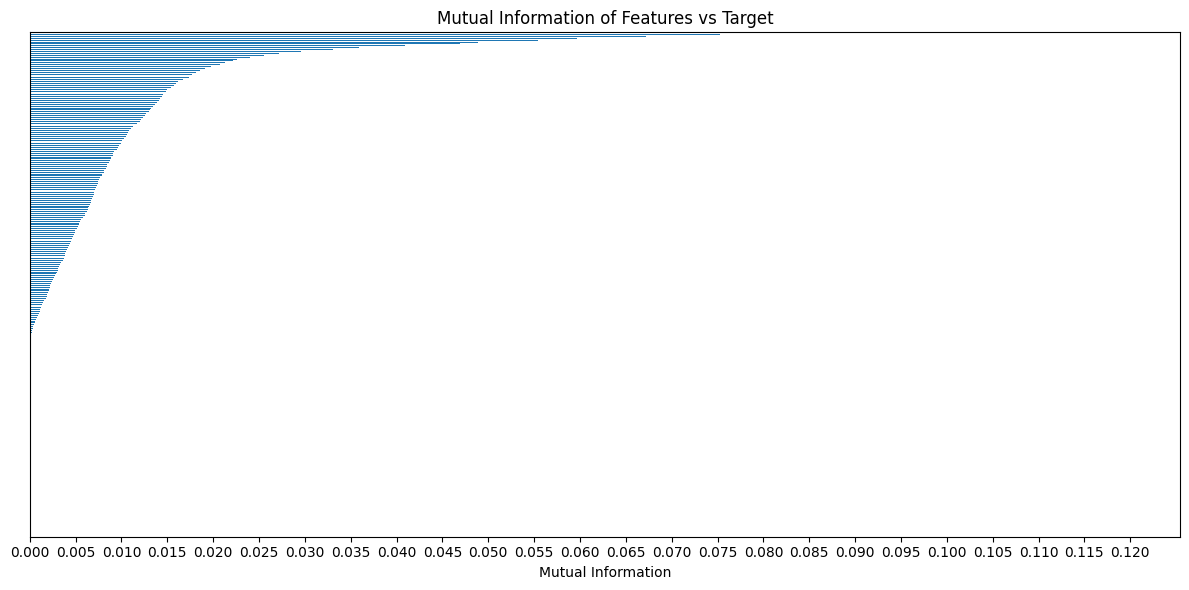

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
mi_series.sort_values(ascending=True).plot(kind='barh')
plt.title('Mutual Information of Features vs Target')
plt.xlabel('Mutual Information')
plt.ylabel('')
plt.yticks([])
plt.xticks(np.arange(0, mi_series.max() + 0.005, 0.005))

plt.tight_layout()
plt.show()


In [39]:
threshold = 0.00001
to_drop = mi_series[mi_series < threshold].index
df_filtered = df_reduced.drop(columns=to_drop)

print(f"Keeping {df_filtered.shape[1]} features from original {df_reduced.shape[1]}")


Keeping 1060 features from original 1751


### Create data split

In [38]:
from sklearn.model_selection import train_test_split

X = df_filtered.drop('target', axis=1)
y = df_filtered['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (3000, 1059)
Test set shape: (751, 1059)


## Configuration